In [3]:
import numpy as np
import matplotlib.pyplot as plt
import allantools 
import pandas as pd 
from datetime import date, timedelta
from astropy.time import Time

In [36]:
N = 1000 # Num of points

# Generate noise
sample = np.random.uniform(0, 1, size=(1000,))

sdate = date(2021,1,25)   # start date
edate = date(2023,10,22)   # end date

# Generate dates
dates = pd.date_range(sdate,edate-timedelta(days=1),freq='d').to_julian_date()

# Convert to astropy Time object
t = Time(dates.values, format='jd')

# Besselian year
t_by = t.byear

# Generate random error
# err = np.random.uniform(size=1000)



In [38]:
np.average(sample)

0.5046699249414566

In [39]:
df = pd.DataFrame({'Data':sample,'Besselian':t_by})
df

,Data,Besselian
0,0.787208,2021.068120
1,0.171479,2021.070858
2,0.430857,2021.073596
3,0.733253,2021.076334
4,0.690897,2021.079072
...,...,...
995,0.239083,2023.792340
996,0.802422,2023.795078
997,0.286749,2023.797816
998,0.005187,2023.800554


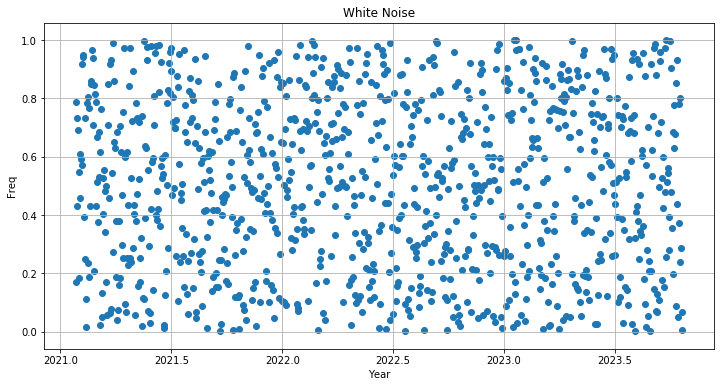

In [40]:
plt.figure(figsize=(12,6))
plt.title('White Noise')
plt.scatter(df['Besselian'], df['Data'])
plt.xlabel('Year')
plt.ylabel('Freq')
plt.grid()

In [41]:
def allanoadev(y,dates):
        
    # === Parameters ===
    
    # Length of observation
    N = len(y)
        
    # m array where 3 < m < N/3 
#     m = np.arange(3,1+round(N//3),1)
    m = np.array([1])
    # Take tau0 as 1/rate
    tau0 =  np.mean(np.diff(dates))
    # steps
    step = 1
    
    # Empty variance array
    allanvar = []
    # Empty tau values array 
    tau = []
    
    # Iterate over values of m
    for k in range(len(m)): 
        print('Current value of m: ', m[k])
        # Sliding windows 
        left = 0 
        right = m[k]
        ybar = []
        D = 0
        data_sum = 0
        
        # Check for missing windows 
        while right <= N:
            avg = np.average(y[left:right])
            ybar.append(avg)
                
            left += step 
            right += step    
            

        M_D = len(ybar)

        # Calculate allan var 
        outersum = []
        j = 0
        while j < M_D-2*m[k]+1:
            i = j
            ysum = []
            while i <= j+m[k]-1:
                ysum.append(ybar[i+m[k]]-ybar[i])
                i += 1
            outersum.append(0.5*(np.sum(ysum)/m[k])**2)
            j += 1


        # Calculate allan variance
        allanvar.append(np.sum(outersum)/(M_D-2*m[k]+1))
        
        # Calculate tau
        tau.append(tau0*m[k])

    # Calculate allan std dev
    allanstd = np.sqrt(allanvar)
        
    return tau, allanstd


In [42]:
tau, allanstd = allanoadev(df['Data'],df['Besselian'])

Current value of m:  1


In [43]:
allanstd

array([0.28724567])